In [1]:
ROOT = '../..' # Relative position of the root folder.
MODE = 'triplets'

In [2]:
import sys
sys.path.append(ROOT)

In [3]:
from libs import ConfigLoader

cfg_loader = ConfigLoader(f'{ROOT}/configs/cfg.yaml')
cfgs = cfg_loader.get_configs()
print(cfgs)

{'using_kaggle': False, 'input_folder': 'kaggle/input', 'use_dataset': 'asl-dataset', 'kaggle_override': {'input_folder': 'kaggle/input'}, 'data': {'asl-dataset': {'path': 'synthetic-asl-alphabet', 'train': 'Train_Alphabet', 'test': 'Test_Alphabet'}, 'roboflow-asl-dataset-1': {'path': 'roboflow-asl-alphabet-1', 'train': 'train', 'test': 'test'}}, 'output': {'path': 'models/output'}}


In [4]:
from libs import ASLDataLoader

data_loader = ASLDataLoader(cfgs)
data_loader.check()

using_kaggle: False
use_dataset: asl-dataset
input_folder: c:\kht\ai\AI Projects (Local)\fyp\major-fyp-2024\kaggle\input\synthetic-asl-alphabet
train_data_path: c:\kht\ai\AI Projects (Local)\fyp\major-fyp-2024\kaggle\input\synthetic-asl-alphabet\Train_Alphabet
test_data_path: c:\kht\ai\AI Projects (Local)\fyp\major-fyp-2024\kaggle\input\synthetic-asl-alphabet\Test_Alphabet
dataset: None
dataloader: None


In [5]:
data_loader.display_data_info(train=True)

Number of images: 24300
Number of unique classes: 27


In [6]:
data_loader.display_data_info(train=False)

Number of images: 2700
Number of unique classes: 27


In [7]:
from torchvision import transforms

In [8]:
transform = transforms.Compose([
    transforms.Resize((512, 512)),
    transforms.ToTensor(),
])

In [9]:
train_dataset = data_loader.get_dataset(train=True, transform=transform, mode=MODE)

In [10]:
import os
import random
from libs import visualize_dataloader_triplets

In [11]:
class_id = random.choice(os.listdir(data_loader.train_data_path))
folder_path = os.path.join(data_loader.train_data_path, class_id)
print(f'Samples from {os.path.basename(data_loader.train_data_path)}')
# visualize_sample_images(folder_path)

Samples from Train_Alphabet


In [12]:
import torchvision.transforms as transforms

desired_height, desired_width = 512, 512
data_transforms = transforms.Compose([
    transforms.ToTensor(),
    transforms.RandomRotation(degrees=10),  # Rotation range
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),  # Width and height shift
    transforms.RandomHorizontalFlip(),  # Horizontal flip
    transforms.RandomResizedCrop(size=(desired_height, desired_width), scale=(0.8, 1.0)),  # Zoom
    
    # transforms.Resize((desired_height, desired_width)),  # Ensure consistent size
])

In [13]:
train_loader = data_loader.get_dataloader(train=True, mode=MODE, transform=data_transforms)

In [14]:
train_loader.dataset

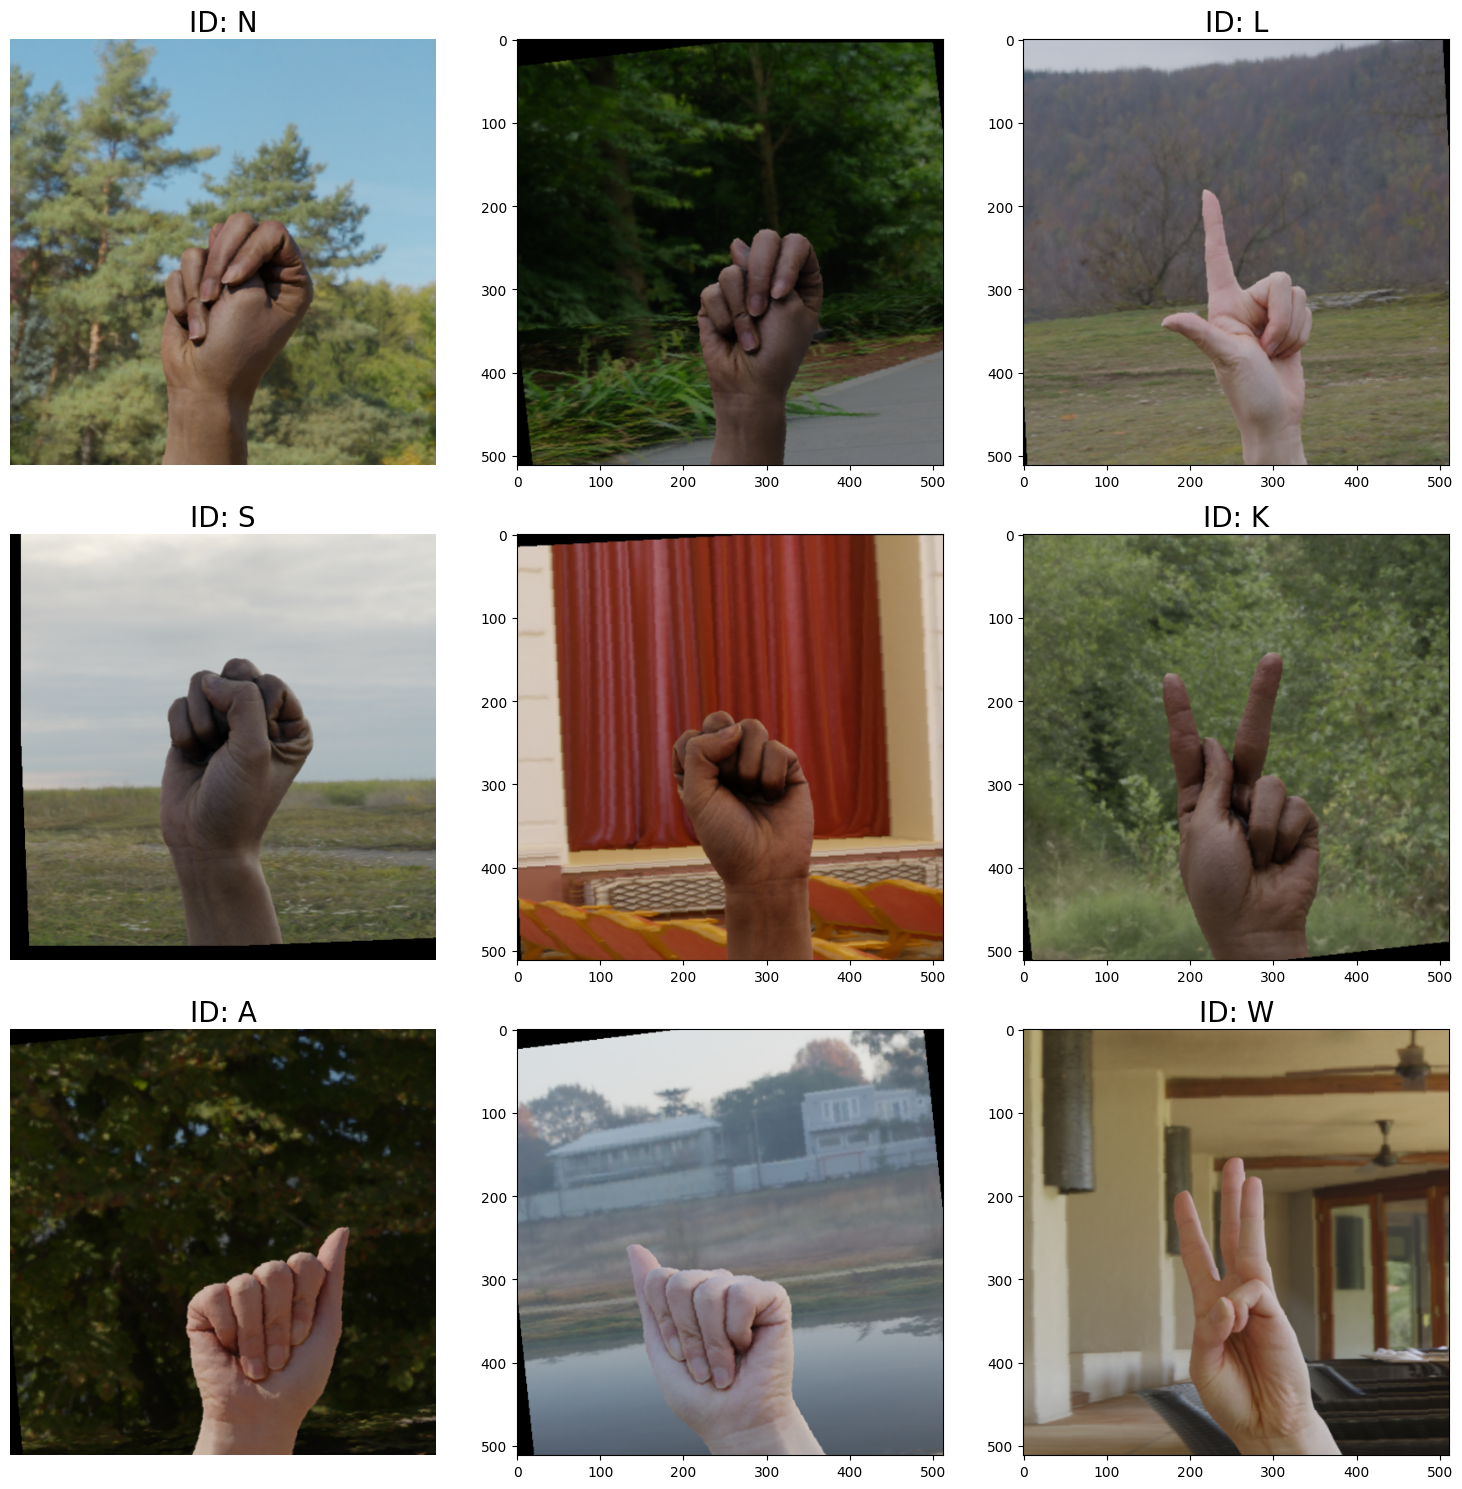

In [15]:
visualize_dataloader_triplets(train_loader)

In [16]:
from libs.models.efficientnet_mlp_classifier import SimpleClassifier

In [17]:
model = SimpleClassifier(num_classes=len(train_dataset.classes))

Loaded pretrained weights for efficientnet-b7
Num layers: 9


In [18]:
print(model)

SimpleClassifier(
  (model): EfficientNet(
    (_conv_stem): Conv2dStaticSamePadding(
      3, 64, kernel_size=(3, 3), stride=(2, 2), bias=False
      (static_padding): ZeroPad2d((0, 1, 0, 1))
    )
    (_bn0): BatchNorm2d(64, eps=0.001, momentum=0.010000000000000009, affine=True, track_running_stats=True)
    (_blocks): ModuleList(
      (0): MBConvBlock(
        (_depthwise_conv): Conv2dStaticSamePadding(
          64, 64, kernel_size=(3, 3), stride=[1, 1], groups=64, bias=False
          (static_padding): ZeroPad2d((1, 1, 1, 1))
        )
        (_bn1): BatchNorm2d(64, eps=0.001, momentum=0.010000000000000009, affine=True, track_running_stats=True)
        (_se_reduce): Conv2dStaticSamePadding(
          64, 16, kernel_size=(1, 1), stride=(1, 1)
          (static_padding): Identity()
        )
        (_se_expand): Conv2dStaticSamePadding(
          16, 64, kernel_size=(1, 1), stride=(1, 1)
          (static_padding): Identity()
        )
        (_project_conv): Conv2dStaticSamePa

In [19]:
from libs.trainers.trainer_triplet import train_one_epoch, test_one_epoch, TripletLoss
import torch.nn as nn
from torchvision import transforms
from torch.optim import Adam

In [43]:
test_loader_triplet = data_loader.get_dataloader(train=False, mode=MODE)

In [21]:
criterion = TripletLoss()
optimizer = Adam(model.parameters(), lr=1e-4)

In [22]:
num_epochs = 20 # 30
device = 'cuda'

In [23]:
# Move model to the specified device (GPU or CPU)
model.to(device)
train_losses, train_accus, test_losses, test_accus = [], [], [], []

for epoch in range(num_epochs):
    train_loss = train_one_epoch(model, train_loader, criterion, optimizer, device=device, num_epochs=num_epochs, epoch=epoch)
    test_loss = test_one_epoch(model, test_loader, criterion, device=device)
    train_losses.append(train_loss)
    test_losses.append(test_loss)

Epoch 1: 100%|██████████| 254/254 [18:55<00:00,  4.47s/it]


Epoch 1/20, Loss: 6.4216


Testing: 100%|██████████| 29/29 [01:39<00:00,  3.44s/it]


Test Loss: 1.2347


Epoch 2: 100%|██████████| 254/254 [18:40<00:00,  4.41s/it]


...

Test Loss: 0.2103


Epoch 20: 100%|██████████| 254/254 [18:37<00:00,  4.40s/it]


Epoch 20/20, Loss: 0.5363


Testing: 100%|██████████| 29/29 [01:38<00:00,  3.40s/it]

Test Loss: 0.1721


In [44]:
for epoch in range(num_epochs, num_epochs*2):
    train_loss = train_one_epoch(model, train_loader, criterion, optimizer, device=device, num_epochs=num_epochs, epoch=epoch)
    test_loss = test_one_epoch(model, test_loader_triplet, criterion, device=device)
    train_losses.append(train_loss)
    test_losses.append(test_loss)

Epoch 21: 100%|██████████| 254/254 [18:57<00:00,  4.48s/it]


Epoch 21/20, Loss: 0.4963


Testing: 100%|██████████| 29/29 [01:39<00:00,  3.44s/it]


Test Loss: 0.2560


Epoch 22: 100%|██████████| 254/254 [18:56<00:00,  4.48s/it]


...

Test Loss: 0.0484


Epoch 40: 100%|██████████| 254/254 [19:24<00:00,  4.59s/it]


Epoch 40/20, Loss: 0.2052


Testing: 100%|██████████| 29/29 [01:43<00:00,  3.58s/it]

Test Loss: 0.0570


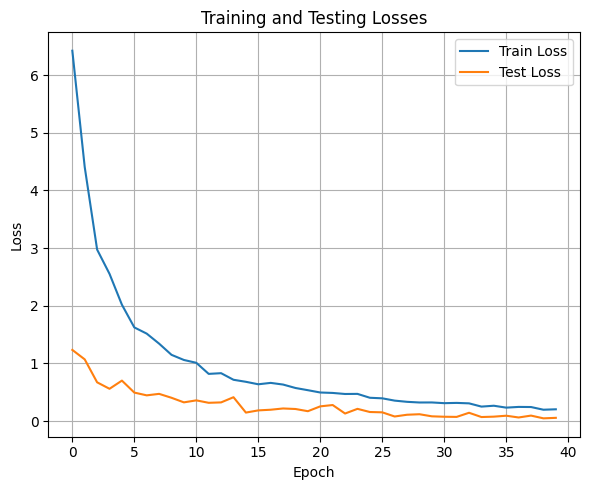

In [45]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(1, 1, figsize=(6, 5))
axs = [axs]
axs[0].plot(train_losses, label='Train Loss')
axs[0].plot(test_losses, label='Test Loss')
axs[0].set_title('Training and Testing Losses')
axs[0].set_xlabel('Epoch')
axs[0].set_ylabel('Loss')
axs[0].legend()
axs[0].grid()

# axs[1].plot(train_accus, label='Train Accuracy')
# axs[1].plot(test_accus, label='Test Accuracy')
# axs[1].set_title('Training and Testing Accuracies')
# axs[1].set_xlabel('Epoch')
# axs[1].set_ylabel('Accuracy')
# axs[1].legend()
# axs[1].grid()

plt.tight_layout()

plt.show()

In [47]:
test_one_epoch(model, test_loader_triplet, criterion, device=device)

Testing: 100%|██████████| 29/29 [01:59<00:00,  4.14s/it]

Test Loss: 0.0677


0.0677165605834332

In [48]:
from libs.model_loader import save_model, load_model

In [49]:
save_model(model, f'{ROOT}/saved_models/model-2024-10-31-triplet.pth')

Model saved to ../../saved_models/model-2024-10-31-triplet.pth


In [50]:
# Load the model
loaded_model = SimpleClassifier(num_classes=27)
loaded_model = load_model(loaded_model, f'{ROOT}/saved_models/model-2024-10-31-triplet.pth')

Loaded pretrained weights for efficientnet-b7
Num layers: 9


c:\kht\ai\AI Projects (Local)\fyp\major-fyp-2024\tests\3_modularization_test\../..\libs\model_loader.py:12: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_di

Model loaded from ../../saved_models/model-2024-10-31-triplet.pth


In [52]:
loaded_model.to(device)
test_one_epoch(loaded_model, test_loader_triplet, criterion, device=device)

Testing: 100%|██████████| 29/29 [01:38<00:00,  3.39s/it]

Test Loss: 0.1056


0.10557209637722578

In [53]:
from libs.verifiers.verifier import extract_features, plot_tsne

In [54]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

In [55]:
test_loader = data_loader.get_dataloader(train=False, mode='standard')

In [56]:
features, labels = extract_features(loaded_model, test_loader)

100%|██████████| 85/85 [01:37<00:00,  1.15s/it]


In [57]:
classes = test_loader.dataset.unique_labels
labels_id = [classes[label] for label in labels]

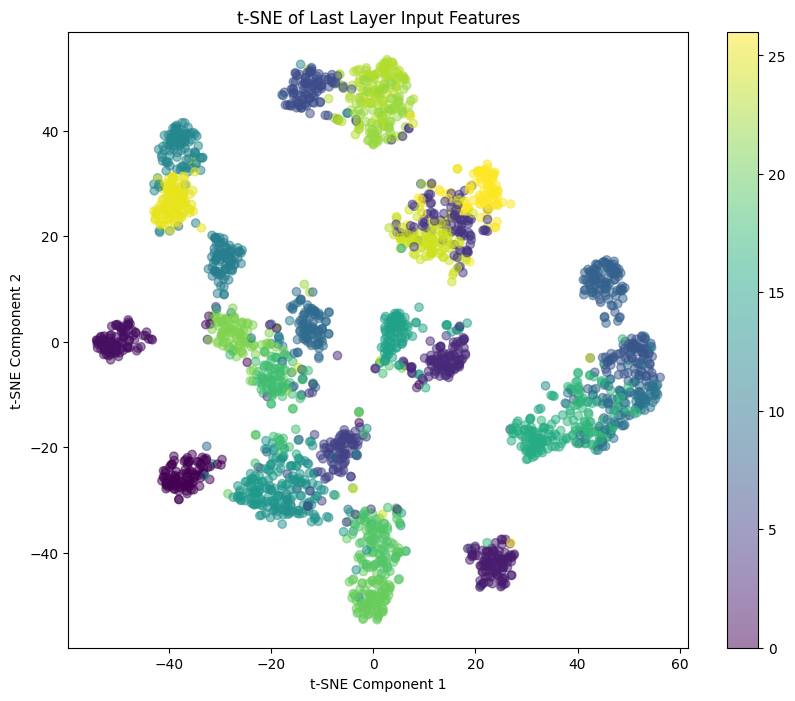

In [58]:
plot_tsne(features, labels_id)

In [59]:
from libs.verifiers.verifier import plot_similarity_matrix

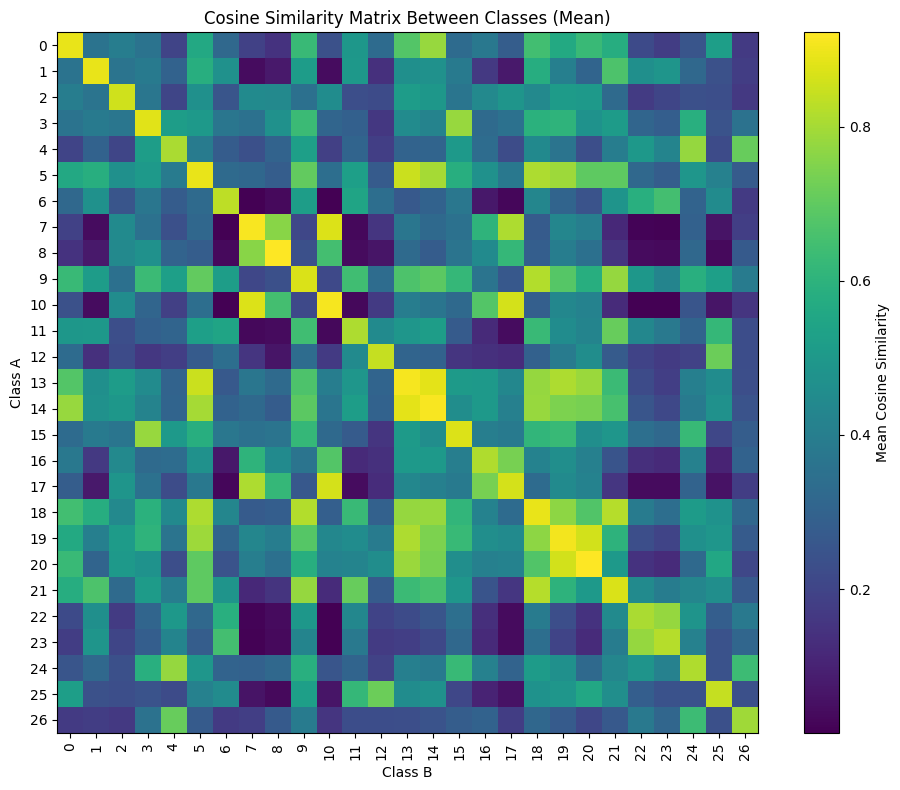

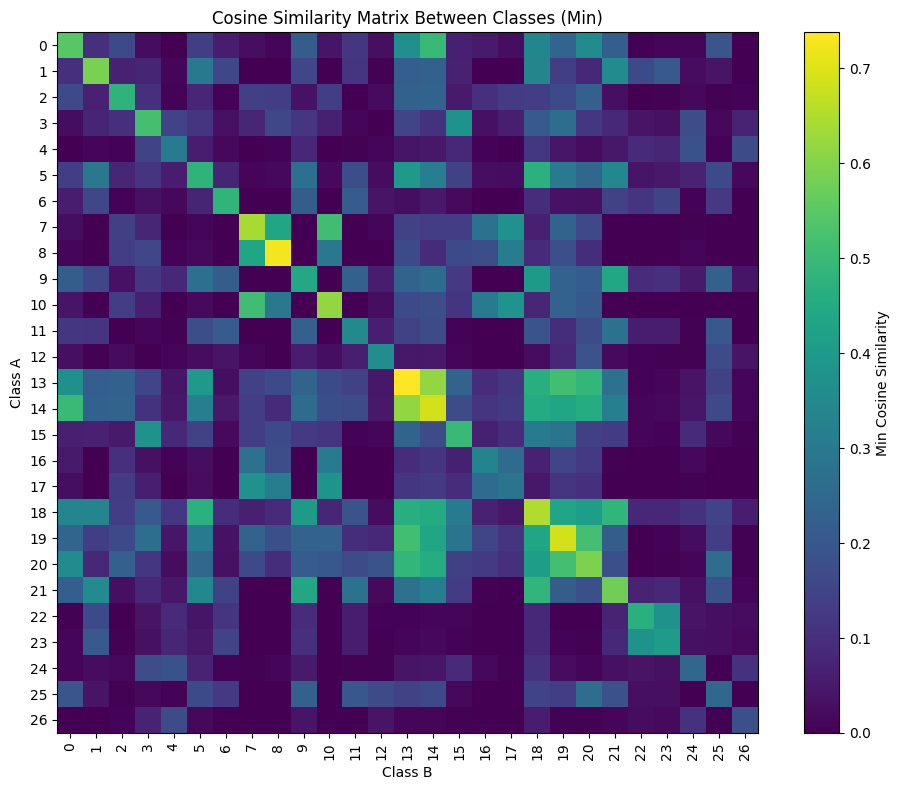

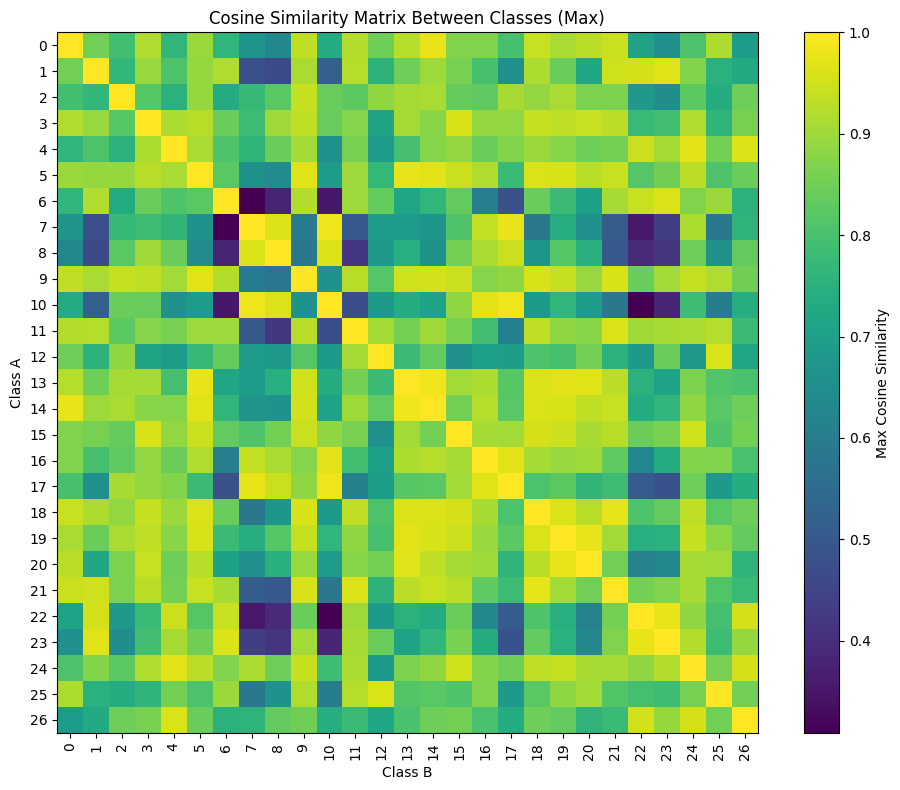

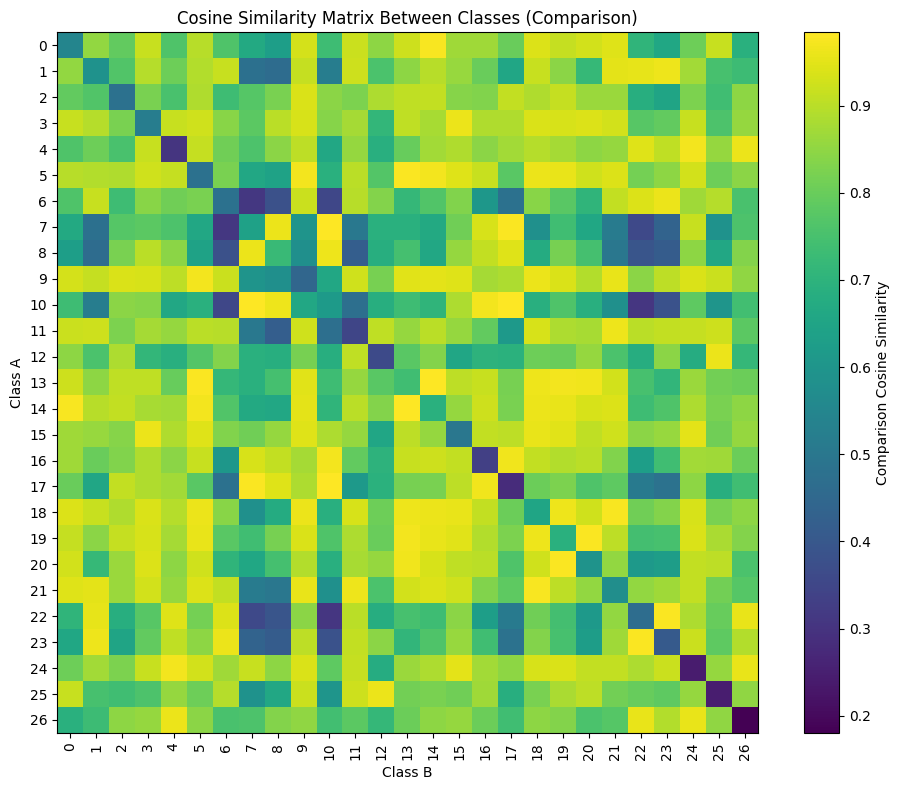

array([[[0.89056212, 0.35953322, 0.40013477, ..., 0.25280297,
         0.52292949, 0.16623773],
        [0.35953325, 0.89126211, 0.36459196, ..., 0.32016182,
         0.23953813, 0.1780605 ],
        [0.40013477, 0.36459196, 0.85777128, ..., 0.23699258,
         0.23140623, 0.16276963],
        ...,
        [0.252803  , 0.32016182, 0.2369926 , ..., 0.81475556,
         0.24317496, 0.63774377],
        [0.52292955, 0.23953816, 0.23140623, ..., 0.24317496,
         0.84071916, 0.2367101 ],
        [0.16623773, 0.1780605 , 0.16276962, ..., 0.63774377,
         0.2367101 , 0.79258728]],

       [[0.54608709, 0.10258894, 0.16159624, ..., 0.01070595,
         0.19370176, 0.00214271],
        [0.10258894, 0.59011352, 0.06910886, ..., 0.02499346,
         0.03841549, 0.        ],
        [0.16159624, 0.06910886, 0.48029947, ..., 0.01501247,
         0.00422229, 0.00595069],
        ...,
        [0.01070595, 0.02499346, 0.01501247, ..., 0.24240488,
         0.00268917, 0.1055668 ],
        [0.1

In [60]:
plot_similarity_matrix(features, labels_id)